# Cuantización Vectorial de Aprendizaje (LVQ)

**Descripción:**

LVQ (*Learning Vector Quantization*) es un algoritmo de aprendizaje supervisado **basado en instancias** (o basado en prototipos) propuesto por Teuvo Kohonen en 1986, como una adaptación supervisada de sus mapas autoorganizados (*Self-Organizing Maps*). A diferencia de un árbol de decisión o una red neuronal, LVQ no aprende reglas ni una función paramétrica global: representa cada clase mediante uno o varios **prototipos** (también llamados *vectores código* o *codebook vectors*) — puntos en el mismo espacio que los datos de entrenamiento — y clasifica un ejemplo nuevo asignándole la clase del prototipo más cercano (típicamente por distancia euclidiana). Es, en esencia, la misma regla de decisión que usa 1-NN, pero evaluada contra un conjunto pequeño y **aprendido** de prototipos en vez de contra todo el conjunto de entrenamiento. El entrenamiento ajusta iterativamente la posición de los prototipos: en su versión original (LVQ1), por cada ejemplo se identifica el prototipo más cercano y se lo desplaza hacia el ejemplo si la clase coincide, o se lo aleja si no coincide. Variantes posteriores (LVQ2.1, LVQ3) refinan esta regla cerca de la frontera de decisión, y la **Cuantización Vectorial de Aprendizaje Generalizada** (GLVQ, Sato y Yamada, 1995) reformula la actualización como descenso de gradiente sobre una función de costo diferenciable, lo que abre la puerta a extensiones que además aprenden una métrica de distancia propia (GRLVQ, GMLVQ).

**Bibtex y Referencias:**

```bibtex
@incollection{kohonen1995learning,
  title={Learning vector quantization},
  author={Kohonen, Teuvo},
  booktitle={Self-organizing maps},
  pages={245--261},
  year={1995},
  publisher={Springer}
}

@article{hammer2014learning,
  title={Learning vector quantization for (dis-) similarities},
  author={Hammer, Barbara and Hofmann, Daniela and Schleif, Frank-Michael and Zhu, Xibin},
  journal={Neurocomputing},
  volume={131},
  pages={43--51},
  year={2014},
  publisher={Elsevier}
}

@inproceedings{sato1995generalized,
  title={Generalized Learning Vector Quantization},
  author={Sato, Atsushi and Yamada, Keiji},
  booktitle={Advances in Neural Information Processing Systems (NeurIPS)},
  volume={8},
  year={1995}
}

@article{vanveen2021sklvq,
  title={sklvq: Scikit Learning Vector Quantization},
  author={van Veen, Rick and Biehl, Michael and de Vries, Gert-Jan},
  journal={Journal of Machine Learning Research},
  volume={22},
  number={231},
  pages={1--6},
  year={2021}
}
```

**Tipo de Modelo:**
- **Método de aprendizaje:** Aprendizaje supervisado — clasificación (existen adaptaciones para regresión, pero quedan fuera del alcance de este notebook)
- **Por parámetros:** Parcialmente paramétrico — a diferencia de KNN (verdaderamente no paramétrico, memoriza todo el conjunto de entrenamiento), LVQ fija de antemano el número de prototipos por clase; una vez fijado, ese es el "tamaño" del modelo, independiente de cuántos ejemplos de entrenamiento haya
- **Datos de aprendizaje:** Incremental/online por diseño original (LVQ1 actualiza un prototipo a la vez, ejemplo por ejemplo), aunque en la práctica — y en implementaciones modernas tipo GLVQ — se entrena por lotes iterando varias épocas sobre el dataset
- **Resultado del entrenamiento:** Un caso híbrido dentro del aprendizaje basado en instancias: el modelo entrenado sigue siendo un conjunto de puntos (prototipos) en el espacio de atributos — igual que KNN — y la predicción usa la misma regla del vecino más cercano, pero a diferencia de KNN (perezoso/*lazy*, sin fase de entrenamiento) LVQ sí tiene una fase de entrenamiento explícita (ansioso/*eager*) que comprime el dataset completo en un puñado de prototipos representativos

**Alg. Entrenamiento:**
- Se inicializa un número fijo de prototipos por clase (aleatoriamente entre ejemplos de esa clase, o mediante k-means dentro de cada clase).
- **LVQ1:** para cada ejemplo de entrenamiento se identifica el prototipo más cercano y se actualiza con una regla de atracción/repulsión — se mueve hacia el ejemplo si las clases coinciden, o se aleja si no coinciden — con una tasa de aprendizaje que decae con las iteraciones.
- **LVQ2.1/LVQ3** refinan esa regla actualizando el par de prototipos (uno correcto, uno incorrecto) cuando el ejemplo cae dentro de una "ventana" cerca de la frontera de decisión, para ajustar mejor esa frontera.
- **GLVQ** (la variante usada en este notebook, vía el paquete `sklvq`) reformula el entrenamiento como la minimización de una función de costo diferenciable, basada en la diferencia relativa entre la distancia al prototipo correcto más cercano y la distancia al prototipo incorrecto más cercano, optimizada por descenso de gradiente — a diferencia de LVQ1/2.1/3, tiene una función objetivo explícita y converge de forma más estable.

**Supuestos y Restricciones:**
- Asume que cada clase puede representarse razonablemente bien mediante un número pequeño de prototipos en el espacio de atributos; si las fronteras entre clases son muy irregulares o multimodales, hacen falta varios prototipos por clase (hiperparámetro `prototype_n_per_class` en `sklvq`).
- Al basarse en distancias (euclidianas por defecto), es sensible a la escala de las variables, igual que KNN: requiere estandarizar/normalizar los atributos antes de entrenar.
- El número de prototipos por clase es el hiperparámetro más importante: muy pocos no capturan la complejidad real de las fronteras de decisión; demasiados acercan el modelo a KNN y le hacen perder su principal ventaja frente a este (compresión del dataset y predicción más rápida).
- Las variantes clásicas de Kohonen (LVQ1/2.1/3) son reglas heurísticas sin garantía de convergencia a un óptimo bajo una función de costo bien definida; GLVQ corrige esto formulando el entrenamiento como una optimización explícita, a costa de mayor complejidad de implementación.
- **scikit-learn no implementa LVQ de forma nativa** (no existe una clase `LVQClassifier` en sklearn); usaremos el paquete de terceros **`sklvq`**, compatible con la API de scikit-learn, que implementa GLVQ, GMLVQ y LGMLVQ (ver advertencias de compatibilidad de versión en la siguiente celda).

# Cuantización Vectorial de Aprendizaje: LVQ con `sklvq`

**Advertencia importante antes de empezar:** scikit-learn no implementa LVQ de ninguna variante — no existe una clase `LVQClassifier`. Usamos el paquete de terceros **[`sklvq`](https://github.com/rickvanveen/sklvq)** (Scikit Learning Vector Quantization, van Veen, Biehl & de Vries, *JMLR* 2021), que implementa **GLVQ** (Generalized LVQ) siguiendo la API de scikit-learn (`fit`/`predict`/`score`). No es un paquete oficial de scikit-learn y su última versión en PyPI es de 2021 — trátalo como herramienta de investigación/docencia, no de producción crítica.

LVQ y KNN son ambos algoritmos de **aprendizaje basado en instancias**: los dos clasifican por cercanía en el espacio de atributos. La diferencia está en *contra qué* se mide esa cercanía:

| | **KNN** (`KNeighborsClassifier`, sklearn) | **LVQ / GLVQ** (`sklvq`) |
|---|---|---|
| Representación del modelo | Todo el conjunto de entrenamiento | Un puñado de **prototipos** aprendidos (pocos por clase) |
| Fase de entrenamiento | Ninguna — perezoso (*lazy*), solo almacena los datos | Sí — ansioso (*eager*), ajusta los prototipos por descenso de gradiente |
| Costo de predicción | Crece con el tamaño del dataset (compara contra cada punto almacenado) | Constante una vez fijado el número de prototipos, independiente del tamaño del dataset original |
| Regla de clasificación | Voto mayoritario entre los *k* vecinos más cercanos | Clase del prototipo más cercano (un solo "vecino", pero aprendido, no un dato crudo) |
| Interpretabilidad | Ejemplos reales como explicación, pero potencialmente muchos | Prototipos como "arquetipos" de cada clase — pocos y explícitos |
| Sensibilidad a la escala de las variables | Alta (basado en distancias) | Alta (basado en distancias) |
| Implementación en Python | Oficial, incluida en scikit-learn | Paquete de terceros (`sklvq`), no oficial |

Para ilustrar esta diferencia usamos el dataset **Iris**, reducido a 2 atributos (largo y ancho de pétalo) — las dos variables que mejor separan las 3 especies. Reducir a 2 dimensiones nos deja dibujar la visualización más característica de LVQ: la **frontera de decisión** aprendida junto con los **prototipos** que la generan, y comparar de forma muy directa cuántos "puntos de referencia" necesita cada algoritmo para lograr una precisión similar (los ~120 ejemplos de entrenamiento completos en KNN, contra unos pocos prototipos en LVQ).

**Requisitos:** `numpy`, `pandas`, `matplotlib`, `scikit-learn` (preinstalados en Google Colab) + **`sklvq`**, que instalamos en la siguiente celda. La última versión de `sklvq` en PyPI (0.1.2, 2021) usa un método interno de scikit-learn (`BaseEstimator._validate_data`) que versiones ≥ 1.7 eliminaron, así que fijamos `scikit-learn==1.5.2` explícitamente. Si Colab ya había importado scikit-learn en esta sesión antes de instalar la versión fijada, reinicia el entorno de ejecución (*Entorno de ejecución → Reiniciar sesión*) después de instalar y antes de correr el resto del notebook.

In [1]:
!pip install -q "scikit-learn==1.5.2" sklvq


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklvq import GLVQ

np.random.seed(42)  # reproducibilidad

## 1. Cargar datos de ejemplo

Usamos el dataset **Iris** (incluido en scikit-learn), quedándonos solo con **largo y ancho de pétalo** — las dos variables que mejor separan las 3 especies — para poder dibujar la frontera de decisión en 2D más adelante. Con las 4 variables completas el modelo sería ligeramente más preciso, pero perderíamos la visualización directa de los prototipos.

In [3]:
iris = load_iris()
feature_names = [iris.feature_names[2], iris.feature_names[3]]  # petal length, petal width
X = iris.data[:, [2, 3]]
y = iris.target
class_names = list(iris.target_names)

df_preview = pd.DataFrame(X, columns=feature_names)
df_preview["especie"] = pd.Categorical.from_codes(y, class_names)
df_preview.head()

,petal length (cm),petal width (cm),especie
0,1.4,0.2,setosa
1,1.4,0.2,setosa
2,1.3,0.2,setosa
3,1.5,0.2,setosa
4,1.4,0.2,setosa


## 2. Visualizar los datos crudos

Cada color es una especie. LVQ aprenderá un puñado de prototipos dentro de cada nube de puntos, y KNN (para comparar más adelante) usará la nube completa.

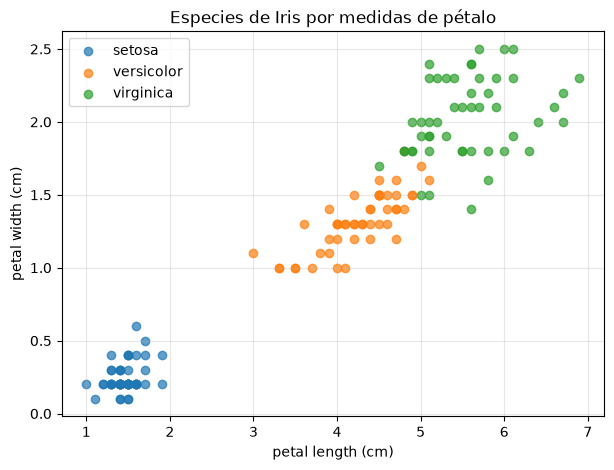

In [4]:
plt.figure(figsize=(7, 5))
for class_idx, class_name in enumerate(class_names):
    mask = y == class_idx
    plt.scatter(X[mask, 0], X[mask, 1], label=class_name, alpha=0.7)
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Especies de Iris por medidas de pétalo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Dividir y escalar los datos

A diferencia de los árboles de decisión (invariantes a la escala), LVQ y KNN se basan en **distancias** — sin escalar, una variable con rango numérico mayor dominaría el cálculo de distancia frente a las demás. Ajustamos el `StandardScaler` **solo** con los datos de entrenamiento y lo aplicamos igual a entrenamiento y prueba, para no filtrar información del conjunto de prueba.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Entrenamiento: {X_train_s.shape[0]} muestras | Prueba: {X_test_s.shape[0]} muestras")

Entrenamiento: 120 muestras | Prueba: 30 muestras


## 4. Entrenar un clasificador GLVQ

`GLVQ` sigue la API de scikit-learn: `fit`/`predict`/`score`. Por defecto inicializa **un prototipo por clase** (`prototype_n_per_class=1`) y los ajusta minimizando la función de costo de GLVQ por descenso de gradiente. Tras entrenar, `prototypes_` contiene las coordenadas aprendidas y `prototypes_labels_` la clase de cada uno.

In [6]:
glvq = GLVQ(random_state=42)
glvq.fit(X_train_s, y_train)

y_pred_glvq = glvq.predict(X_test_s)
acc_glvq = accuracy_score(y_test, y_pred_glvq)

print(f"Precisión (GLVQ): {acc_glvq:.3f}")
print(f"Número de prototipos aprendidos: {glvq.prototypes_.shape[0]} (uno por clase, por defecto)")
for coords, label in zip(glvq.prototypes_, glvq.prototypes_labels_):
    print(f"  Prototipo de '{class_names[label]}': {feature_names[0]}={coords[0]:.2f}, {feature_names[1]}={coords[1]:.2f} (escalado)")

Precisión (GLVQ): 0.967
Número de prototipos aprendidos: 3 (uno por clase, por defecto)
  Prototipo de 'setosa': petal length (cm)=-1.32, petal width (cm)=-1.26 (escalado)
  Prototipo de 'versicolor': petal length (cm)=0.21, petal width (cm)=0.06 (escalado)
  Prototipo de 'virginica': petal length (cm)=1.00, petal width (cm)=1.09 (escalado)


## 5. Visualizar la frontera de decisión y los prototipos

Esta es la visualización más característica de LVQ: las regiones de color muestran a qué clase asignaría el modelo cualquier punto del plano, y los diamantes marcan los **prototipos** que generan esas regiones — cada punto del plano se clasifica según cuál de esos pocos diamantes tiene más cerca.

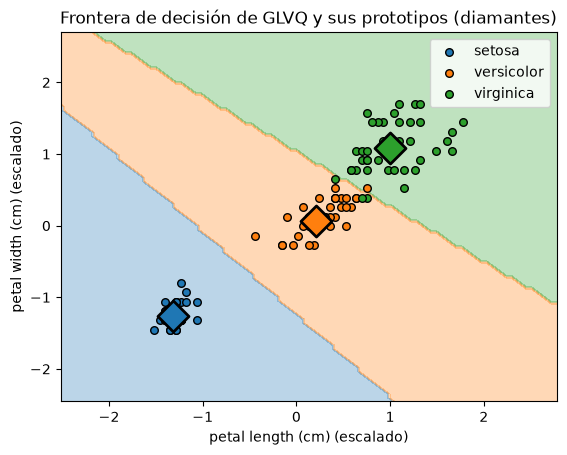

In [7]:
disp = DecisionBoundaryDisplay.from_estimator(
    glvq, X_train_s, alpha=0.3, response_method="predict", cmap="tab10", vmin=-0.5, vmax=9.5
)
for class_idx, class_name in enumerate(class_names):
    mask = y_train == class_idx
    plt.scatter(X_train_s[mask, 0], X_train_s[mask, 1], label=class_name, edgecolor="k", s=30)

for coords, label in zip(glvq.prototypes_, glvq.prototypes_labels_):
    plt.scatter(coords[0], coords[1], marker="D", s=250, c=f"C{label}", edgecolor="black", linewidth=2)

plt.xlabel(f"{feature_names[0]} (escalado)")
plt.ylabel(f"{feature_names[1]} (escalado)")
plt.title("Frontera de decisión de GLVQ y sus prototipos (diamantes)")
plt.legend()
plt.show()

## 6. Matriz de confusión y reporte de clasificación

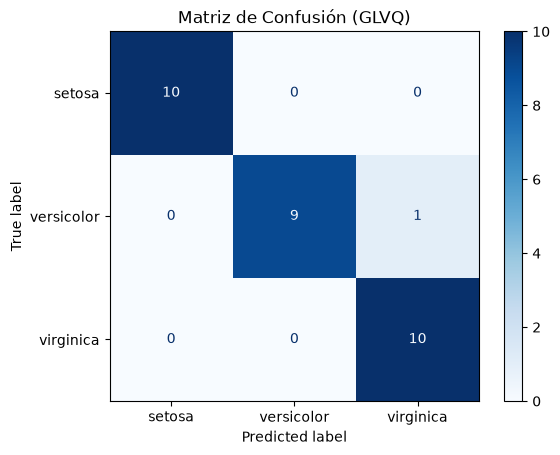

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [8]:
cm = confusion_matrix(y_test, y_pred_glvq)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión (GLVQ)")
plt.show()

print(classification_report(y_test, y_pred_glvq, target_names=class_names))

## 7. LVQ vs. KNN: ¿cuántos puntos hacen falta para decidir?

Entrenamos un `KNeighborsClassifier` sobre los mismos datos escalados. La pregunta no es solo "¿cuál es más preciso?" sino **"¿cuántos puntos de referencia necesita cada uno para decidir?"** — esa es la diferencia práctica entre un método basado en instancias que memoriza todo (KNN) y uno que las comprime en prototipos (LVQ): KNN debe conservar y recorrer cada ejemplo de entrenamiento en cada predicción, mientras que GLVQ solo necesita comparar contra sus pocos prototipos, sin importar qué tan grande sea el dataset original.

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)
acc_knn = accuracy_score(y_test, knn.predict(X_test_s))

comparison = pd.DataFrame({
    "modelo": ["KNN (k=5)", "GLVQ"],
    "precisión": [acc_knn, acc_glvq],
    "puntos de referencia usados": [X_train_s.shape[0], glvq.prototypes_.shape[0]],
})
comparison

,modelo,precisión,puntos de referencia usados
0,KNN (k=5),0.966667,120
1,GLVQ,0.966667,3


## 8. El hiperparámetro más importante: prototipos por clase

En LVQ el hiperparámetro que más importa es **cuántos prototipos usar por clase** (`prototype_n_per_class`). Muy pocos prototipos pueden no alcanzar para representar fronteras irregulares; demasiados acercan el modelo a KNN y le hacen perder su ventaja de compresión. Barremos varios valores para ver el efecto.

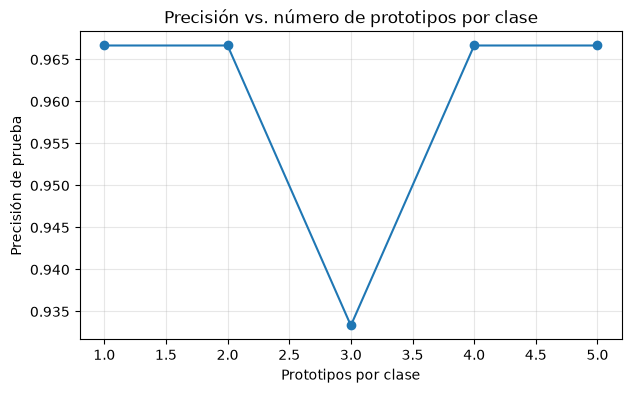

,prototipos por clase,prototipos totales,precisión
0,1,3,0.966667
1,2,6,0.966667
2,3,9,0.933333
3,4,12,0.966667
4,5,15,0.966667


In [10]:
resultados = []
for n in [1, 2, 3, 4, 5]:
    modelo = GLVQ(prototype_n_per_class=n, random_state=42)
    modelo.fit(X_train_s, y_train)
    resultados.append({
        "prototipos por clase": n,
        "prototipos totales": modelo.prototypes_.shape[0],
        "precisión": accuracy_score(y_test, modelo.predict(X_test_s)),
    })

ablation = pd.DataFrame(resultados)

plt.figure(figsize=(7, 4))
plt.plot(ablation["prototipos por clase"], ablation["precisión"], marker="o")
plt.xlabel("Prototipos por clase")
plt.ylabel("Precisión de prueba")
plt.title("Precisión vs. número de prototipos por clase")
plt.grid(True, alpha=0.3)
plt.show()

ablation

## 9. Predecir sobre muestras nuevas

Tomamos 3 flores reales del conjunto de prueba —nunca vistas durante el entrenamiento— y comparamos la especie real contra la predicha por el GLVQ entrenado en la sección 4.

In [11]:
sample_positions = [0, 1, 2]  # tres flores de prueba, elegidas arbitrariamente

for pos in sample_positions:
    real = class_names[y_test[pos]]
    predicha = class_names[glvq.predict(X_test_s[pos].reshape(1, -1))[0]]
    atributos = dict(zip(feature_names, X_test[pos]))
    print(f"Real: {real:11s} | Predicho: {predicha:11s}")
    print(f"  Atributos: {atributos}\n")

Real: setosa      | Predicho: setosa     
  Atributos: {'petal length (cm)': 1.3, 'petal width (cm)': 0.2}

Real: virginica   | Predicho: virginica  
  Atributos: {'petal length (cm)': 4.9, 'petal width (cm)': 1.8}

Real: versicolor  | Predicho: versicolor 
  Atributos: {'petal length (cm)': 3.3, 'petal width (cm)': 1.0}



## 10. Bonus: los prototipos como imágenes (dataset Digits)

Con Iris los prototipos son solo dos números por flor, difíciles de interpretar más allá del gráfico de la sección 5. El dataset **Digits** (dígitos manuscritos de 8×8 píxeles, incluido en scikit-learn) deja ver el concepto de "prototipo" de forma mucho más directa: cada prototipo aprendido por GLVQ **es literalmente una imagen** — el "dígito promedio" que el modelo aprendió para representar a cada clase — y podemos dibujarlo junto a un ejemplo real de esa clase.

Precisión (GLVQ sobre Digits, 1 prototipo por clase): 0.889


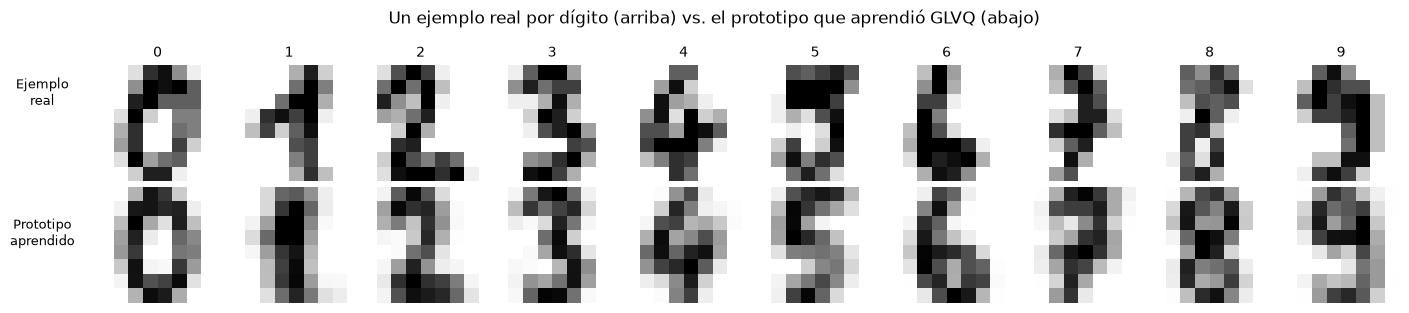

In [12]:
digits = load_digits()
Xd, yd = digits.data, digits.target
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    Xd, yd, test_size=0.2, random_state=42, stratify=yd
)

scaler_d = StandardScaler().fit(Xd_train)
Xd_train_s, Xd_test_s = scaler_d.transform(Xd_train), scaler_d.transform(Xd_test)

glvq_digits = GLVQ(random_state=42)
glvq_digits.fit(Xd_train_s, yd_train)
acc_digits = accuracy_score(yd_test, glvq_digits.predict(Xd_test_s))
print(f"Precisión (GLVQ sobre Digits, 1 prototipo por clase): {acc_digits:.3f}")

# Volvemos los prototipos a la escala original de píxeles (0-16) para poder dibujarlos
prototipos_pixeles = np.clip(scaler_d.inverse_transform(glvq_digits.prototypes_), 0, 16)

fig, axes = plt.subplots(2, 10, figsize=(14, 3.2))
for digit in range(10):
    ejemplo_real = Xd_train[yd_train == digit][0].reshape(8, 8)
    axes[0, digit].imshow(ejemplo_real, cmap="gray_r")
    axes[0, digit].set_title(str(digit), fontsize=10)
    axes[0, digit].axis("off")

    proto_idx = list(glvq_digits.prototypes_labels_).index(digit)
    prototipo = prototipos_pixeles[proto_idx].reshape(8, 8)
    axes[1, digit].imshow(prototipo, cmap="gray_r")
    axes[1, digit].axis("off")

fig.text(0.02, 0.72, "Ejemplo\nreal", ha="center", va="center", fontsize=9)
fig.text(0.02, 0.28, "Prototipo\naprendido", ha="center", va="center", fontsize=9)
plt.suptitle("Un ejemplo real por dígito (arriba) vs. el prototipo que aprendió GLVQ (abajo)")
plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()

## 11. Alternativas de LVQ

`sklvq` cubre GLVQ, GMLVQ y LGMLVQ, pero si esta tarea requiere otras variantes o una implementación más probada, existen alternativas:

- **[`sklearn-lvq`](https://github.com/MrNuggelz/sklearn-lvq)** (paquete `sklearn-lvq` en PyPI, de MrNuggelz): también compatible con scikit-learn, cubre además **GRLVQ**, **RSLVQ**, **MRSLVQ** y variantes con matrices de relevancia local (**LGMLVQ**). Tiene un enfoque y una base de código distintos a `sklvq`, y tampoco es un paquete con mantenimiento activo constante — conviene revisar qué versión de scikit-learn soporta antes de usarlo.
- **Java / Weka:** Weka no incluye LVQ de forma nativa en su distribución estándar, pero existen paquetes de terceros para su ecosistema; en la práctica, para trabajos de curso suele ser más simple quedarse en Python con `sklvq` o `sklearn-lvq`.
- **Implementación propia:** el algoritmo LVQ1 original (sección "Alg. Entrenamiento" al inicio del notebook) es lo bastante simple como para programarlo desde cero en unas pocas líneas de NumPy si el objetivo del curso es entender la regla de actualización, más que usar una librería.